# Pertemuan 11 — Unsupervised Learning: Clustering (K-Means & Hierarchical)

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 5 Juli 2026

---

## Tujuan Notebook
Aktivitas hands-on Pertemuan 11 — melakukan **segmentasi pelanggan** menggunakan **Clustering** (*Unsupervised Learning*), sebuah transisi penting dari materi *Supervised Learning* (Pertemuan 7–10). Kali ini data **tidak memiliki label**; algoritma yang harus menemukan sendiri struktur pengelompokannya:

1. Generate & eksplorasi dataset pelanggan sintetis (3 kelompok tersembunyi: hemat, menengah, boros)
2. **Preprocessing** — memilih fitur numerik & **StandardScaler** (skala fitur setara sebelum menghitung jarak)
3. **Metode Elbow** — plot **WCSS** untuk K=1..10 guna menentukan jumlah cluster **K optimal**
4. **Silhouette Score** sebagai pembanding yang lebih objektif untuk memilih K final
5. Melatih **KMeans** dengan K optimal, lalu **memprofilkan** & memberi nama tiap segmen
6. **Visualisasi** scatter plot berwarna + posisi centroid
7. **Hierarchical Clustering** (Ward linkage) sebagai pembanding + membaca **dendrogram**

> **Catatan konteks:** karena ini *unsupervised*, tidak ada "jawaban benar" berupa label. Keberhasilan diukur dari seberapa **rapat (kompak)** anggota tiap cluster dan seberapa **terpisah** antar cluster — diukur lewat **WCSS/inertia** (makin kecil makin rapat) dan **Silhouette Score** (mendekati +1 makin baik).


## Langkah 1 — Generate & Eksplorasi Dataset

Dataset dibangun **sintetis** agar notebook reprodusibel tanpa file eksternal, meniru skenario **segmentasi pelanggan** dunia nyata. Tiga kelompok pelanggan "tersembunyi" ditanam sengaja — nanti kita uji apakah K-Means dapat menemukannya kembali **tanpa diberi tahu labelnya**:

| Kelompok tersembunyi | Karakter | pendapatan_tahunan (juta Rp) | skor_belanja (1–100) |
|---|---|---|---|
| Grup 1 | Hemat | rendah (~30) | rendah (~20) |
| Grup 2 | Menengah | sedang (~70) | sedang (~55) |
| Grup 3 | Boros/Premium | tinggi (~110) | tinggi (~85) |

Fitur `usia` dan `gender` ikut dibuat sebagai konteks, namun **clustering fokus pada dua fitur perilaku** (`pendapatan_tahunan`, `skor_belanja`) agar mudah divisualisasikan dalam scatter plot 2D.


In [1]:
# Langkah 1: Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

# Tiga kelompok dibuat dari distribusi normal dengan pusat & sebaran berbeda
grp1 = np.random.normal([30, 20],  [6, 8],  (100, 2))   # hemat
grp2 = np.random.normal([70, 55],  [8, 10], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))   # boros / premium
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=["pendapatan_tahunan", "skor_belanja"])
# Batasi ke rentang wajar sesuai deskripsi dataset pada modul
df["pendapatan_tahunan"] = df["pendapatan_tahunan"].clip(15, 150)
df["skor_belanja"]       = df["skor_belanja"].clip(1, 100)
df["usia"]   = np.random.randint(18, 65, len(df))
df["gender"] = np.random.choice(["L", "P"], len(df))

print("Shape:", df.shape)
print("\n5 baris pertama:")
print(df.head())
print("\nStatistik deskriptif:")
print(df.describe().round(2))


Shape: (300, 4)

5 baris pertama:
   pendapatan_tahunan  skor_belanja  usia gender
0           32.980285     18.893886    64      P
1           33.886131     32.184239    21      P
2           28.595080     18.126904    29      L
3           39.475277     26.139478    62      L
4           27.183154     24.340480    19      L

Statistik deskriptif:
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.22   42.07
std                 33.82         27.38   13.59
min                 15.00          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        100.00   64.00


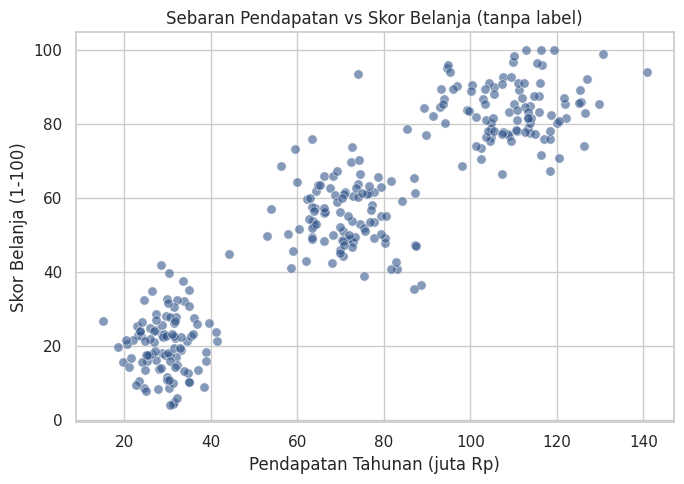

In [2]:
# EDA: sebaran pendapatan vs skor belanja (belum diberi warna cluster)
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="pendapatan_tahunan", y="skor_belanja",
                color="#34568B", alpha=0.6, s=45)
plt.title("Sebaran Pendapatan vs Skor Belanja (tanpa label)")
plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja (1-100)")
plt.tight_layout()
plt.show()


**Bacaan EDA:**
- Secara visual sudah **terlihat tiga gumpalan (blob)** yang cukup terpisah pada bidang *pendapatan × skor belanja*. Ini pertanda kuat bahwa data memang punya struktur kelompok — kondisi ideal untuk K-Means yang mengasumsikan cluster berbentuk **bulat (spherical)**.
- Meski begitu, algoritma **tidak "melihat" gambar ini**; ia hanya menghitung jarak. Tugas kita berikutnya adalah membuktikan secara kuantitatif (via Elbow & Silhouette) bahwa **K=3** adalah pilihan terbaik.


## Langkah 2 — Preprocessing (StandardScaler)

K-Means bekerja berbasis **jarak Euclidean**, sehingga fitur dengan **rentang besar akan mendominasi** perhitungan jarak jika tidak diskalakan. `pendapatan_tahunan` (15–150) punya rentang jauh lebih lebar dari `skor_belanja` (1–100), maka kita samakan skalanya dengan **StandardScaler** (mean = 0, std = 1).

> Tanpa scaling, cluster akan condong terbentuk hanya berdasarkan pendapatan dan mengabaikan perilaku belanja.


In [3]:
# Langkah 2: Pilih fitur numerik relevan + StandardScaler
from sklearn.preprocessing import StandardScaler

X = df[["pendapatan_tahunan", "skor_belanja"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling:", X_scaled.mean(axis=0).round(3))
print("Std setelah scaling      :", X_scaled.std(axis=0).round(3))
print("\nContoh 3 baris X_scaled:\n", np.round(X_scaled[:3], 3))


Rata-rata setelah scaling: [0. 0.]
Std setelah scaling      : [1. 1.]

Contoh 3 baris X_scaled:
 [[-1.095 -1.256]
 [-1.069 -0.769]
 [-1.225 -1.284]]


## Langkah 3 — Metode Elbow untuk Menentukan K

**WCSS** (*Within-Cluster Sum of Squares* = `inertia_` di scikit-learn) selalu **menurun** saat K bertambah — jadi kita **tidak boleh** memilih K hanya dari WCSS terkecil (K = jumlah data ⇒ WCSS = 0). Metode **Elbow** mencari **titik siku**: K di mana penurunan WCSS mulai **melandai tajam**. Setelah titik itu, menambah cluster hanya memberi perbaikan kecil (indikasi *overfitting* / cluster terlalu granular).


In [4]:
# Langkah 3: Hitung WCSS untuk K = 1..10
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, init="k-means++", n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Tabel WCSS + penurunan antar-K (Delta) agar titik elbow terlihat kuantitatif
deltas = [np.nan] + [wcss[i-1] - wcss[i] for i in range(1, len(wcss))]
tabel_elbow = pd.DataFrame({
    "K": list(K_range),
    "WCSS (inertia)": np.round(wcss, 2),
    "Penurunan (Delta)": np.round(deltas, 2),
})
print(tabel_elbow.to_string(index=False))


 K  WCSS (inertia)  Penurunan (Delta)
 1          600.00                NaN
 2          161.49             438.51
 3           44.37             117.12
 4           37.68               6.68
 5           31.26               6.43
 6           25.69               5.57
 7           21.44               4.25
 8           18.83               2.61
 9           17.23               1.60
10           15.92               1.31


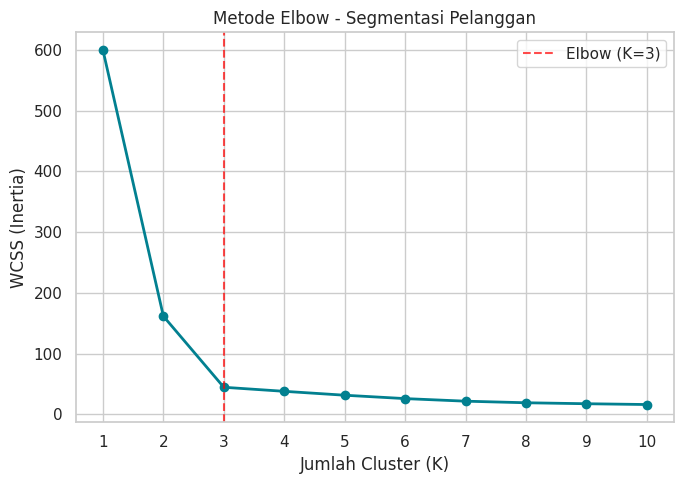

In [5]:
# Plot grafik Elbow
plt.figure(figsize=(7, 5))
plt.plot(list(K_range), wcss, marker="o", color="#028090", linewidth=2)
plt.axvline(x=3, color="red", linestyle="--", alpha=0.7, label="Elbow (K=3)")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Metode Elbow - Segmentasi Pelanggan")
plt.xticks(list(K_range))
plt.legend()
plt.tight_layout()
plt.show()


**Bacaan grafik Elbow:**
- Penurunan WCSS **sangat tajam** dari K=1 → K=2 → K=3, lalu **mendadak melandai** setelah K=3 (Delta jatuh dari ratusan menjadi hanya satuan). Bentuk "siku" muncul jelas di **K=3**.
- Ini **konsisten dengan tiga kelompok tersembunyi** yang kita tanam di Langkah 1 — K-Means berhasil menebak struktur data tanpa diberi label.
- Karena kurva melandai mulus setelahnya, kita **konfirmasi** pilihan ini dengan Silhouette Score di Langkah 4.


## Langkah 4 — Silhouette Score sebagai Pembanding

Titik elbow kadang **subjektif**. **Silhouette Score** memberi ukuran yang lebih objektif: seberapa cocok tiap titik dengan clusternya sendiri dibanding cluster tetangga terdekat. Nilainya **−1 s/d +1** (makin mendekati **+1** makin baik pemisahannya). Kita bandingkan beberapa kandidat K, lalu pilih yang **skornya tertinggi**.


In [6]:
# Langkah 4: Silhouette Score untuk K = 2..7
from sklearn.metrics import silhouette_score

hasil_sil = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, init="k-means++", n_init=10).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    hasil_sil.append((k, round(sil, 3)))
    print(f"K={k}: Silhouette = {sil:.3f}")

k_terbaik = max(hasil_sil, key=lambda t: t[1])
print(f"\n=> Silhouette tertinggi pada K={k_terbaik[0]} (skor {k_terbaik[1]}) "
      f"- sejalan dengan titik elbow.")


K=2: Silhouette = 0.635
K=3: Silhouette = 0.696
K=4: Silhouette = 0.581
K=5: Silhouette = 0.481
K=6: Silhouette = 0.372
K=7: Silhouette = 0.394

=> Silhouette tertinggi pada K=3 (skor 0.696) - sejalan dengan titik elbow.


## Langkah 5 — Melatih Model K-Means Final (K=3)

**Elbow (siku di K=3)** dan **Silhouette (skor tertinggi di K=3)** sepakat, jadi kita latih model final dengan **K=3**. Lalu kita **profilkan** tiap cluster (rata-rata pendapatan, skor belanja, usia, dan jumlah anggota) untuk memberi **nama segmen** yang bermakna secara bisnis.

Parameter `init="k-means++"` (default scikit-learn) memilih centroid awal secara cerdas sehingga hasil lebih **stabil** dan WCSS akhir lebih rendah dibanding inisialisasi acak murni.


In [7]:
# Langkah 5: Fit model final + profiling cluster
model = KMeans(n_clusters=3, random_state=42, init="k-means++", n_init=10)
model.fit(X_scaled)
df["cluster"] = model.labels_

print(f"WCSS akhir       : {model.inertia_:.3f}")
print(f"Silhouette Score : {silhouette_score(X_scaled, model.labels_):.3f}\n")

profil = df.groupby("cluster")[["pendapatan_tahunan", "skor_belanja", "usia"]].mean().round(2)
profil["jumlah_anggota"] = df.groupby("cluster").size()
print("Profil rata-rata tiap cluster:")
print(profil)


WCSS akhir       : 44.366
Silhouette Score : 0.696

Profil rata-rata tiap cluster:
         pendapatan_tahunan  skor_belanja   usia  jumlah_anggota
cluster                                                         
0                     70.99         55.05  39.16              99
1                     29.31         20.27  42.33             100
2                    109.20         84.03  44.65             101


In [8]:
# Beri nama segmen berdasarkan profil (pendapatan & skor belanja)
means_inc = df.groupby("cluster")["pendapatan_tahunan"].mean()
urut = means_inc.sort_values().index.tolist()   # cluster termiskin -> terkaya
nama = {urut[0]: "Hemat", urut[1]: "Menengah", urut[2]: "Boros/Premium"}
df["segmen"] = df["cluster"].map(nama)

print("Pemetaan cluster -> nama segmen:")
for c in sorted(nama):
    print(f"  Cluster {c} -> {nama[c]}")
print("\nDistribusi segmen:")
print(df["segmen"].value_counts())


Pemetaan cluster -> nama segmen:
  Cluster 0 -> Menengah
  Cluster 1 -> Hemat
  Cluster 2 -> Boros/Premium

Distribusi segmen:
segmen
Boros/Premium    101
Hemat            100
Menengah          99
Name: count, dtype: int64


## Langkah 6 — Visualisasi Hasil Clustering

Scatter plot berwarna per cluster **pada skala asli** (bukan skala ter-standardisasi) agar mudah diinterpretasikan, lengkap dengan **posisi centroid** (dikembalikan ke skala asli lewat `scaler.inverse_transform`).


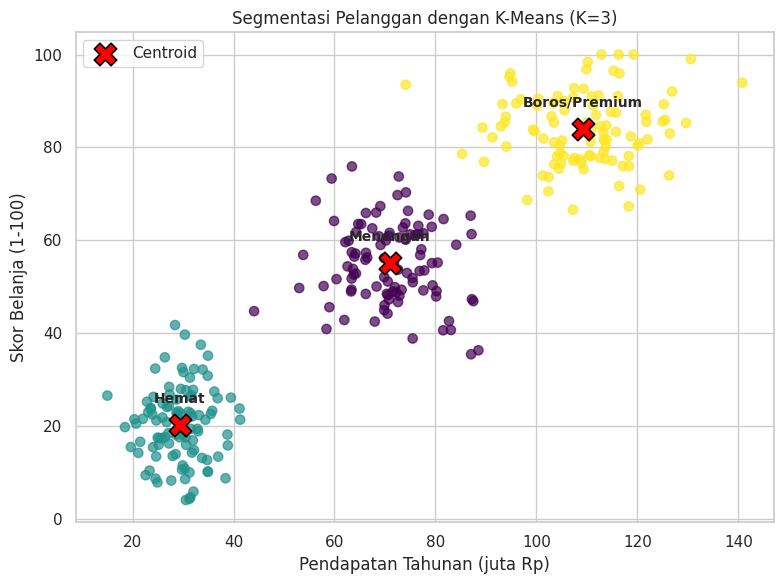

In [9]:
# Langkah 6: Scatter plot berwarna + centroid
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["pendapatan_tahunan"], df["skor_belanja"],
                      c=df["cluster"], cmap="viridis", alpha=0.7, s=45)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c="red", marker="X", s=260, edgecolor="black",
            linewidth=1.2, label="Centroid")
for c in sorted(nama):
    plt.annotate(nama[c], (centroids[c, 0], centroids[c, 1]),
                 textcoords="offset points", xytext=(0, 16),
                 ha="center", fontsize=10, fontweight="bold")
plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja (1-100)")
plt.title("Segmentasi Pelanggan dengan K-Means (K=3)")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretasi tiap segmen:**
- **Cluster "Hemat"** — pendapatan rendah **dan** skor belanja rendah. Strategi: program loyalitas hemat, promo bundling terjangkau.
- **Cluster "Menengah"** — pendapatan & belanja sedang; segmen terbesar dan paling stabil. Strategi: *upselling* bertahap.
- **Cluster "Boros/Premium"** — pendapatan tinggi **dan** skor belanja tinggi. Segmen paling bernilai. Strategi: layanan eksklusif, produk premium, *early access*.

Hasil ini **cocok** dengan tiga kelompok tersembunyi yang ditanam di Langkah 1 — bukti bahwa K-Means menemukan struktur nyata dalam data.


## Langkah 7 — Hierarchical Clustering (Pembanding)

Sebagai pembanding, kita bangun **dendrogram** dengan **Ward linkage** (meminimalkan peningkatan varians dalam cluster — linkage paling umum & hasilnya seimbang). Hierarchical **tidak perlu menentukan K di awal**: kita "memotong" dendrogram pada celah vertikal terpanjang untuk membaca jumlah cluster alami.


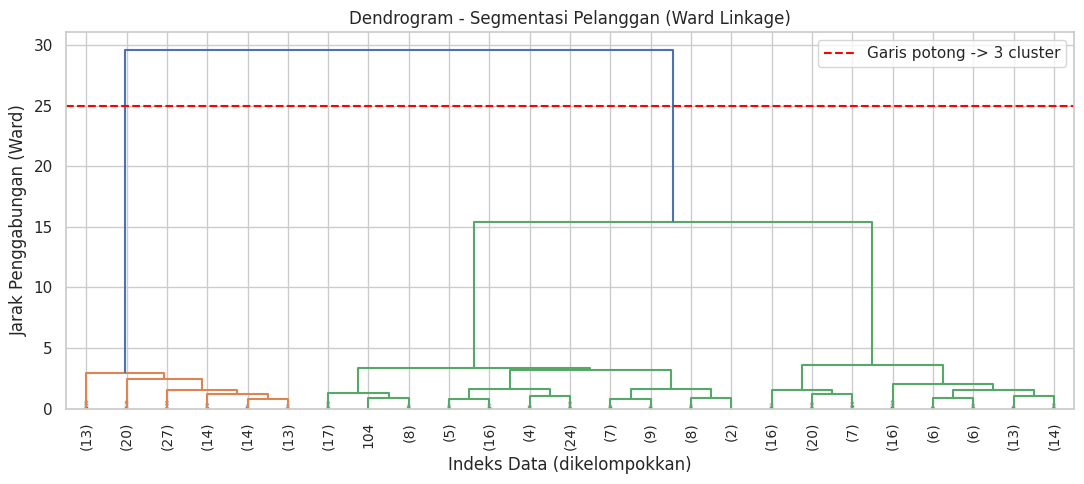

In [10]:
# Langkah 7a: Dendrogram (Ward linkage)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(11, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90., show_contracted=True)
plt.title("Dendrogram - Segmentasi Pelanggan (Ward Linkage)")
plt.xlabel("Indeks Data (dikelompokkan)")
plt.ylabel("Jarak Penggabungan (Ward)")
plt.axhline(y=25, color="red", linestyle="--", label="Garis potong -> 3 cluster")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
# Langkah 7b: Potong dendrogram jadi 3 cluster & bandingkan dengan K-Means
hc_labels = fcluster(Z, t=3, criterion="maxclust")

tabel_banding = pd.crosstab(model.labels_, hc_labels,
                            rownames=["K-Means"], colnames=["Hierarchical"])
print("Tabel silang label K-Means vs Hierarchical (3 cluster):")
print(tabel_banding)

# Hitung tingkat kesesuaian (label bisa berbeda urutan, jadi ambil kecocokan maksimum per baris)
sesuai = tabel_banding.max(axis=1).sum()
total = len(hc_labels)
print(f"\nKesesuaian penempatan: {sesuai}/{total} titik "
      f"({sesuai/total*100:.1f}%) dikelompokkan sama oleh kedua metode.")


Tabel silang label K-Means vs Hierarchical (3 cluster):
Hierarchical    1    2   3
K-Means                   
0               1    0  98
1             100    0   0
2               0  101   0

Kesesuaian penempatan: 299/300 titik (99.7%) dikelompokkan sama oleh kedua metode.


**Bacaan dendrogram & perbandingan:**
- Celah vertikal terpanjang pada dendrogram terpotong menjadi **3 cluster** — **konsisten** dengan K optimal hasil Metode Elbow (Langkah 3).
- Tabel silang menunjukkan **hampir seluruh titik** ditempatkan pada kelompok yang sama oleh K-Means dan Hierarchical (label angka boleh berbeda urutan; yang penting **komposisi anggotanya** sama). Kesepakatan dua algoritma berbeda ini memperkuat keyakinan bahwa **struktur 3 segmen memang nyata**, bukan artefak satu metode.


## Kesimpulan & Refleksi

Pertemuan ini menandai transisi dari **Supervised** (belajar dari `X, y` berlabel) ke **Unsupervised Learning** — di sini algoritma menemukan sendiri struktur data **tanpa label**. Melalui studi kasus **segmentasi pelanggan**, saya mempraktikkan pipeline clustering end-to-end:

1. **Scaling itu wajib** untuk algoritma berbasis jarak seperti K-Means — tanpa `StandardScaler`, fitur berentang besar (pendapatan) akan mendominasi dan mengaburkan perilaku belanja.
2. **Menentukan K bukan tebakan buta.** Metode **Elbow** (siku WCSS) mempersempit kandidat, lalu **Silhouette Score** mengonfirmasinya secara objektif — keduanya sepakat di **K=3**.
3. **Validasi silang antar algoritma.** **Hierarchical Clustering (Ward)** menghasilkan pengelompokan yang **hampir identik** dengan K-Means, memperkuat bahwa 3 segmen (Hemat, Menengah, Boros/Premium) memang struktur nyata.
4. **Clustering menghasilkan nilai bisnis**: label cluster diubah menjadi **nama segmen** yang bisa langsung dipakai tim marketing untuk menyusun strategi berbeda per kelompok.

Pelajaran terpenting: berbeda dari klasifikasi, di *unsupervised learning* **tidak ada akurasi** untuk diandalkan. Keberhasilan diukur dari **kekompakan** (WCSS/inertia rendah) dan **keterpisahan** (Silhouette tinggi) cluster, serta dari **apakah hasilnya masuk akal secara domain**.

---
**Keterbatasan & Pertanyaan Lanjutan:**
- Dataset **sintetis** dengan cluster **spherical yang rapi** — kondisi ideal bagi K-Means. Pada data nyata yang lebih berantakan (cluster tumpang tindih atau bentuk tak beraturan), K-Means bisa gagal; di situ **DBSCAN** (density-based) atau **GMM** (soft clustering) lebih tepat.
- Clustering hanya memakai **2 fitur** agar mudah divisualisasikan. Pada dimensi tinggi, jarak Euclidean jadi kurang bermakna (*curse of dimensionality*) — perlu **PCA** atau reduksi dimensi lebih dulu.
- Pertanyaan: (1) Bagaimana memilih K jika **Elbow dan Silhouette tidak sepakat**? (2) Bagaimana menangani **fitur kategorikal** (`gender`) dalam clustering — apakah K-Prototypes lebih cocok daripada K-Means?
